In [8]:
import pandas as pd
import glob
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt

def results_scatterplot(results_folder, x_metric, y_metric, epochs = None, classes = None, color_by = "epoch"):

    # gather subdirectories
    all_subdirs = []
    for root, dirs, files in os.walk(results_folder):
        for d in dirs:
            
            all_subdirs.append(os.path.join(root, d))
    if epochs is not None:
        pattern = rf"_({'|'.join(map(str, epochs))})$"
        all_subdirs = [d for d in all_subdirs if re.search(pattern, d)]
        

    # gather results
    all_results = []
    for subdir in all_subdirs:
        file_paths = glob.glob(os.path.join(subdir, "*.json"))
        # take subset of classes if needed
        if classes is not None:
            pattern = rf"class_({'|'.join(map(str, classes))})_"
            file_paths = [f for f in file_paths if re.search(pattern, f)]
        all_jsons = []

        for f in file_paths:
            data = pd.read_json(f, typ='series')
            match = re.search(r'class_(\d+)', f)
            if match:
                data['class'] = int(match.group(1))
            else:
                data['class'] = -99  # default value if no match
            all_jsons.append(data)
        df = pd.concat(all_jsons, axis=1).T
        all_results.append(df)
    final_df = pd.concat(all_results, axis=0)


    # plot
    plt.clf()
    sns.set_style("whitegrid")
    colors_list = list(plt.cm.tab20.colors)
    sns.scatterplot(
        data=final_df, 
        x=x_metric, 
        y=y_metric, 
        hue=color_by, 
        palette=colors_list,  # Use the list here
        alpha=0.7,
        edgecolor=None
    )
    # Formatting
    plt.title(f"{x_metric} vs. {y_metric}")
    plt.xlabel(x_metric.capitalize().replace("_", " "))
    plt.ylabel(y_metric.capitalize().replace("_", " "))
    plt.legend(title=color_by.capitalize(), bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.xlim(.6, .95)
    # plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_94538/3540471484.py:48: UserWarning: The palette list has more values (20) than needed (12), which may not be intended.
  sns.scatterplot(


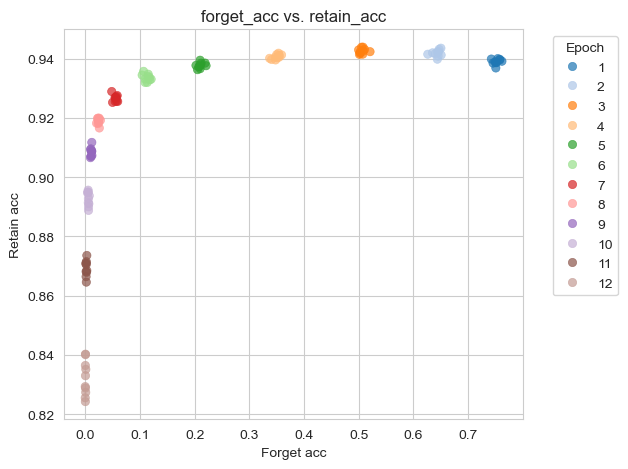

In [22]:
results_scatterplot("results/seed_22/", x_metric = "forget_acc", y_metric = "retain_acc", epochs=None, classes = [3], color_by = "epoch")